In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import re
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, GRU



In [9]:
file = open("C:/Users/Machine learning Projects/Next word Prediction/1661-0.txt", "r", encoding="utf-8")
text = file.read()
print(text[:1000])


﻿
Project Gutenberg's The Adventures of Sherlock Holmes, by Arthur Conan Doyle

This eBook is for the use of anyone anywhere at no cost and with
almost no restrictions whatsoever.  You may copy it, give it away or
re-use it under the terms of the Project Gutenberg License included
with this eBook or online at www.gutenberg.net


Title: The Adventures of Sherlock Holmes

Author: Arthur Conan Doyle

Release Date: November 29, 2002 [EBook #1661]
Last Updated: May 20, 2019

Language: English

Character set encoding: UTF-8

*** START OF THIS PROJECT GUTENBERG EBOOK THE ADVENTURES OF SHERLOCK HOLMES ***



Produced by an anonymous Project Gutenberg volunteer and Jose Menendez



cover



The Adventures of Sherlock Holmes



by Arthur Conan Doyle



Contents


   I.     A Scandal in Bohemia
   II.    The Red-Headed League
   III.   A Case of Identity
   IV.    The Boscombe Valley Mystery
   V.     The Five Orange Pips
   VI.    The Man with the Twisted Lip
   VII.   The Adventure of the Blue 

#### Text cleaning

In [10]:
# Remove Gutenberg metadata (optional but recommended)
start_idx = text.find("*** START OF THIS PROJECT GUTENBERG EBOOK")
end_idx = text.find("*** END OF THIS PROJECT GUTENBERG EBOOK")
if start_idx != -1 and end_idx != -1:
    text = text[start_idx:end_idx]

# Basic cleaning
text = text.lower()
text = re.sub(r"[^a-zA-Z\s]", "", text)  # Keep only letters and spaces
text = re.sub(r"\s+", " ", text)  # Remove multiple spaces
print(text[:500])


 start of this project gutenberg ebook the adventures of sherlock holmes produced by an anonymous project gutenberg volunteer and jose menendez cover the adventures of sherlock holmes by arthur conan doyle contents i a scandal in bohemia ii the redheaded league iii a case of identity iv the boscombe valley mystery v the five orange pips vi the man with the twisted lip vii the adventure of the blue carbuncle viii the adventure of the speckled band ix the adventure of the engineers thumb x the adv


#### Tokenization

In [11]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1
print("Total unique words:", total_words)


Total unique words: 8331


In [12]:
# Use only the first 200,000 words for training
token_list = tokenizer.texts_to_sequences([text])[0]
token_list = token_list[:200000]


In [13]:
input_sequences = []
seq_length = 10  # or 20 if you have more RAM

# Create fixed-length sequences
for i in range(seq_length, len(token_list)):
    n_gram_sequence = token_list[i - seq_length:i + 1]
    input_sequences.append(n_gram_sequence)




In [14]:
# Pad and split
input_sequences = np.array(pad_sequences(input_sequences, maxlen=seq_length + 1, padding='pre'))
xs = input_sequences[:, :-1]
labels = input_sequences[:, -1]
ys = tf.keras.utils.to_categorical(labels, num_classes=total_words)

print("Input shape:", xs.shape)
print("Labels shape:", ys.shape)

Input shape: (104403, 10)
Labels shape: (104403, 8331)


In [15]:
model = Sequential()
model.add(Embedding(input_dim=total_words, output_dim=100))  # 100 = embedding size
model.add(LSTM(150))
model.add(Dense(total_words, activation='softmax'))


In [16]:
ys = labels  # reuse integer labels instead of one-hot

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])


In [17]:
history = model.fit(xs, ys, epochs=10, batch_size=128, verbose=1)


Epoch 1/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 89s 97ms/step - accuracy: 0.0544 - loss: 6.8462
Epoch 2/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 82s 98ms/step - accuracy: 0.0813 - loss: 5.9749
Epoch 3/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 79s 96ms/step - accuracy: 0.1116 - loss: 5.6260
Epoch 4/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 79s 97ms/step - accuracy: 0.1312 - loss: 5.3464
Epoch 5/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 80s 98ms/step - accuracy: 0.1480 - loss: 5.1025
Epoch 6/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 80s 97ms/step - accuracy: 0.1601 - loss: 4.9070
Epoch 7/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 80s 98ms/step - accuracy: 0.1711 - loss: 4.7147
Epoch 8/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 80s 98ms/step - accuracy: 0.1807 - loss: 4.5688
Epoch 9/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 79s 97ms/step - accuracy: 0.1923 - loss: 4.3839
Epoch 10/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 79s 97ms/step - accuracy: 0.2056 - loss: 4.2325


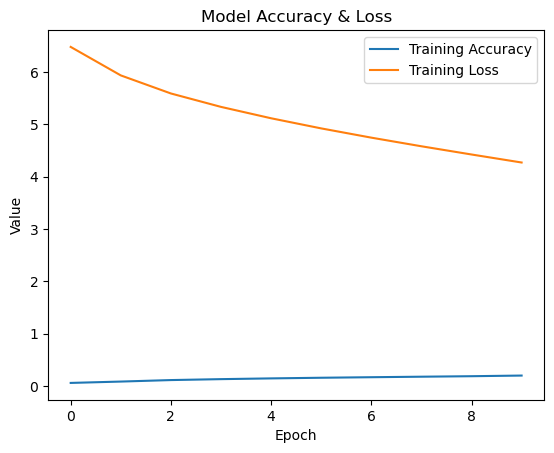

In [19]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['loss'], label='Training Loss')
plt.title('Model Accuracy & Loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.show()

In [20]:
import numpy as np

def predict_next_word(seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=xs.shape[1], padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0))
        
        # Map the predicted token index back to the word
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text


In [21]:
print(predict_next_word("to sherlock holmes she is", next_words=5))
print(predict_next_word("he walked into the", next_words=5))
print(predict_next_word("the night was dark and", next_words=5))


to sherlock holmes she is a little man in the
he walked into the room and i had seen
the night was dark and i had seen the door


In [22]:
model.save("next_word_model.h5")


In [23]:
import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
